# Vehicle Maintenance Prediction Using Machine Learning

## Multiclass Classification of Maintenance Levels

This project aims to predict the maintenance level of vehicles based on vehicle, operational, environmental, and maintenance-related features.

The target variable is **Maintenance Level**, which contains three classes:

* **Normal**
* **Minor**
* **Major**

Several machine learning classification algorithms are implemented and compared to determine which approach provides the best predictive performance.


## 1. Project Overview

In this project, we use a vehicle maintenance dataset to build a machine learning classification system.

The main steps of the project are:

1. Load and inspect the dataset.
2. Analyze the structure and quality of the data.
3. Perform data preprocessing and cleaning.
4. Transform numerical and categorical features into suitable formats.
5. Split the data into training and testing sets.
6. Apply feature scaling where required.
7. Implement multiple machine learning classification models.
8. Evaluate the performance of each model.
9. Compare the models using appropriate evaluation metrics.
10. Determine the best-performing approach.


## 2. Import Libraries and Load the Dataset

The required Python libraries are imported to perform data manipulation, visualization, preprocessing, model training, and evaluation.


In [7]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import train_test_split

# Preprocessing and encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df=pd.read_csv("logistics_sample_15k.csv")
#df=pd.read_csv("logistics_sample_15k.csv")

## 3. Initial Data Inspection

Before preprocessing, the dataset is inspected to understand its structure and identify potential data quality issues.

The following checks are performed:

* Display the first few observations.
* Check for missing values.
* Check for duplicate observations.
* Understand the available features and their data types.


In [8]:
df.isnull().sum()

Vehicle_ID                0
Make_and_Model            0
Year_of_Manufacture       0
Vehicle_Type              0
Usage_Hours               0
Route_Info                0
Load_Capacity             0
Actual_Load               0
Last_Maintenance_Date     0
Maintenance_Type          0
Maintenance_Cost          0
Engine_Temperature        0
Tire_Pressure             0
Fuel_Consumption          0
Battery_Status            0
Vibration_Levels          0
Oil_Quality               0
Brake_Condition           0
Failure_History           0
Anomalies_Detected        0
Predictive_Score          0
Maintenance_Required      0
Weather_Conditions        0
Road_Conditions           0
Delivery_Times            0
Downtime_Maintenance      0
Impact_on_Efficiency      0
Severity_Score            0
Maintenance_Level         0
Maintenance_Level_Code    0
dtype: int64

In [9]:
print(df.head())

     Vehicle_ID   Make_and_Model  Year_of_Manufacture Vehicle_Type  \
0  26721.664851         Volvo FH          2014.952066          Van   
1  59096.884563       Ford F-150          2021.955348        Truck   
2  41923.225586  Chevy Silverado          2020.053203        Truck   
3  71940.550006  Chevy Silverado          2005.957738        Truck   
4  53271.000000       Ford F-150          2014.000000          Van   

   Usage_Hours Route_Info  Load_Capacity  Actual_Load Last_Maintenance_Date  \
0  3882.759556      Rural      45.903636    41.837999            2023-04-12   
1  3133.869072      Urban       9.972567    10.776063            2024-01-08   
2  4342.816756      Urban       3.323578     2.603993            2023-08-22   
3  9654.311487      Rural       4.023934     3.886500            2024-02-18   
4   816.000000      Urban      13.886886    10.756743            2023-02-27   

  Maintenance_Type  ...  Predictive_Score  Maintenance_Required  \
0  Engine Overhaul  ...          0.04

In [10]:
df.duplicated().sum()

np.int64(0)

## 4. Defining the Target Variable and Features

The problem is formulated as a **multiclass classification task**.

The target variable is:

**Maintenance_Level_Code**

where the three classes represent different levels of required maintenance.

The target-related columns are removed from the input features to prevent the model from directly receiving information about the target during training.


In [11]:
y = df['Maintenance_Level_Code']
x = df.drop(columns=[
        'Maintenance_Required',
        'Maintenance_Level',
        'Maintenance_Level_Code',
    ]
)

## 5. Train-Test Split

The dataset is divided into training and testing sets.

* **80%** of the data is used for training.
* **20%** is reserved for testing.

A fixed `random_state` is used to make the results reproducible.

Stratified splitting is applied so that the proportion of the three maintenance-level classes remains approximately the same in both the training and testing sets.


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

## 6. Data Preprocessing

Data preprocessing is performed to prepare the raw dataset for machine learning.

Different preprocessing techniques are applied depending on the characteristics and data type of each feature. These include:

* Handling invalid values and outliers
* Transforming skewed numerical variables
* Encoding categorical variables
* Creating meaningful derived features
* Removing irrelevant or redundant features
* Converting date information into numerical features


### 6.1 Vibration Levels

The distribution of `Vibration_Levels` is examined to identify invalid values and potential skewness.

Negative vibration values are considered invalid and are clipped to zero. A logarithmic transformation is then applied to reduce skewness and make the feature more suitable for machine learning models.



In [13]:
print(x_train['Vibration_Levels'].head())

6025      0.831986
12725     1.903869
10224     2.221088
1949      3.532862
11656    10.525494
Name: Vibration_Levels, dtype: float64


In [14]:
print(x_train['Vibration_Levels'].describe())

count    12000.000000
mean         3.985500
std          4.007889
min         -0.067137
25%          1.153304
50%          2.780060
75%          5.467802
max         40.297611
Name: Vibration_Levels, dtype: float64


In [15]:
x_train['Vibration_Levels'] = x_train['Vibration_Levels'].clip(lower=0)
x_test['Vibration_Levels'] = x_test['Vibration_Levels'].clip(lower=0)

In [16]:
print(x_train['Vibration_Levels'].describe())

count    12000.000000
mean         3.985540
std          4.007849
min          0.000000
25%          1.153304
50%          2.780060
75%          5.467802
max         40.297611
Name: Vibration_Levels, dtype: float64


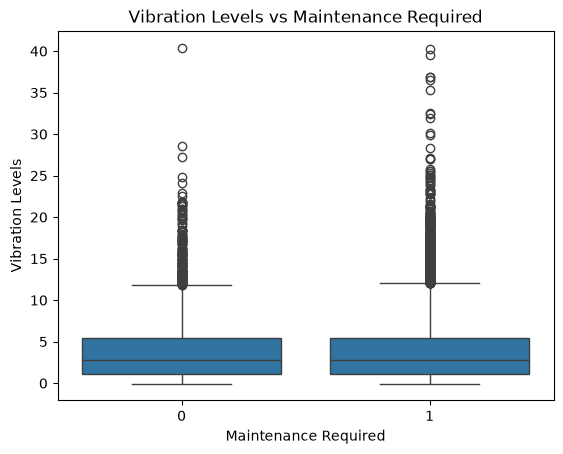

In [17]:
sns.boxplot(x='Maintenance_Required', y='Vibration_Levels', data=df)
plt.xlabel('Maintenance Required')
plt.ylabel('Vibration Levels')
plt.title('Vibration Levels vs Maintenance Required')
plt.show()

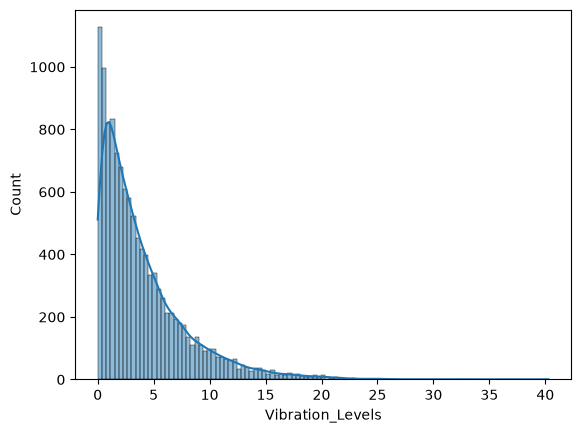

In [18]:
sns.histplot(x_train['Vibration_Levels'], kde=True)
plt.show()

In [19]:
x_train['Vibration_Levels'] = np.log1p(x_train['Vibration_Levels'])
x_test['Vibration_Levels'] = np.log1p(x_test['Vibration_Levels'])

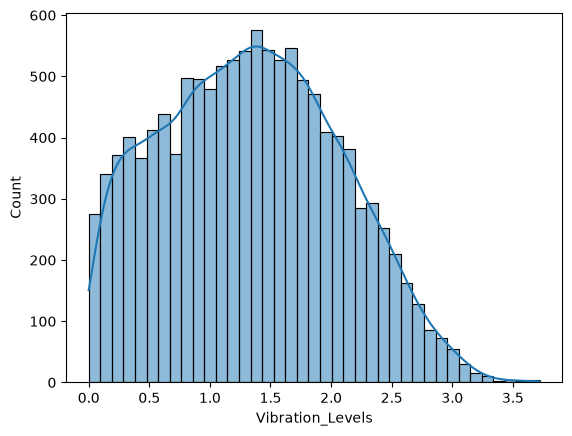

In [20]:
sns.histplot(x_train['Vibration_Levels'], kde=True)
plt.show()

In [21]:
print(x_train['Vibration_Levels'].describe())

count    12000.000000
mean         1.336739
std          0.730805
min          0.000000
25%          0.767004
50%          1.329740
75%          1.866836
max          3.720805
Name: Vibration_Levels, dtype: float64


### 6.2 Oil Quality

The `Oil_Quality` feature is examined using descriptive statistics and a histogram.

Potential outliers are identified using the Interquartile Range (IQR) method. Extreme values are clipped to the calculated bounds, and the feature is also restricted to a maximum value of 100.


In [22]:
print(x_train['Oil_Quality'].describe())

count    12000.000000
mean        79.909876
std          9.855830
min         44.123651
25%         73.224380
50%         79.938856
75%         86.852539
max        100.246089
Name: Oil_Quality, dtype: float64


In [23]:
q25 = x_train['Oil_Quality'].quantile(0.25)
q75 = x_train['Oil_Quality'].quantile(0.75)
iqr = q75 - q25
lower_bound = q25 - (1.5 * iqr)
upper_bound = q75 + (1.5 * iqr)
x_train['Oil_Quality'] = np.where(x_train['Oil_Quality'] > upper_bound, upper_bound, x_train['Oil_Quality'])
x_train['Oil_Quality'] = np.where(x_train['Oil_Quality'] < lower_bound, lower_bound, x_train['Oil_Quality'])
x_test['Oil_Quality']= np.where(x_test['Oil_Quality'] > upper_bound, upper_bound, x_test['Oil_Quality'])
x_test['Oil_Quality']= np.where(x_test['Oil_Quality'] < lower_bound, lower_bound, x_test['Oil_Quality'])

In [24]:
x_train['Oil_Quality'] = x_train['Oil_Quality'].clip(upper=100.0)
x_test['Oil_Quality'] = x_test['Oil_Quality'].clip(upper=100.0)

In [25]:
print(x_train['Oil_Quality'].describe())

count    12000.000000
mean        79.918177
std          9.827686
min         52.782141
25%         73.224380
50%         79.938856
75%         86.852539
max        100.000000
Name: Oil_Quality, dtype: float64


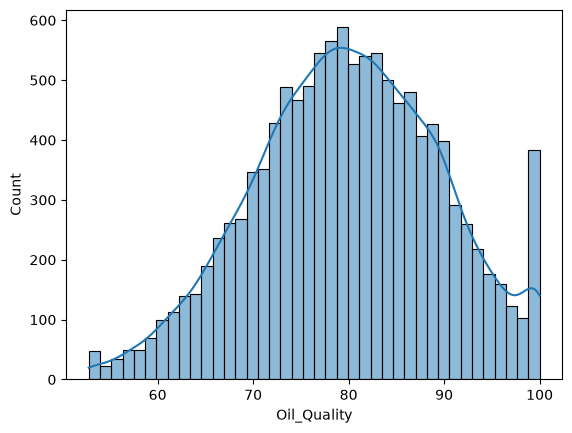

In [26]:
sns.histplot(x_train['Oil_Quality'], kde=True)
plt.show()

### 6.3 Brake Condition

`Brake_Condition` is a categorical feature with three ordered conditions:

* Poor
* Fair
* Good

These categories are converted into numerical values so that machine learning algorithms can process the feature.


In [27]:
brake_mapping = {'Poor': 0, 'Fair': 1, 'Good': 2}
x_train['Brake_Condition'] = x_train['Brake_Condition'].map(brake_mapping)
x_test['Brake_Condition'] = x_test['Brake_Condition'].map(brake_mapping)

### 6.4 Failure History

`Failure_History` is converted into a binary feature.

Values greater than or equal to the selected threshold indicate the presence of failure history, while lower values indicate its absence.


In [28]:
print(x_train['Failure_History'].describe())

count    12000.000000
mean         0.396417
std          0.489175
min         -0.018699
25%          0.000000
50%          0.003019
75%          1.000000
max          1.016051
Name: Failure_History, dtype: float64


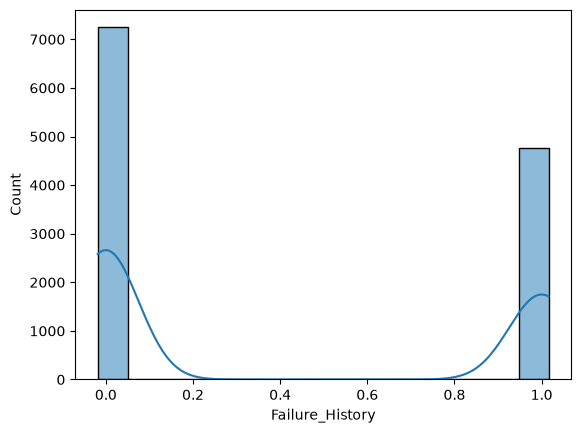

In [29]:
sns.histplot(x_train['Failure_History'], kde=True)
plt.show()

In [30]:
x_train['Failure_History'] = (x_train['Failure_History'] >= 0.5).astype(int)
x_test['Failure_History'] = (x_test['Failure_History'] >= 0.5).astype(int)

In [31]:
print(x_train['Failure_History'].describe())

count    12000.000000
mean         0.396417
std          0.489173
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Failure_History, dtype: float64


### 6.5 Anomalies Detected

The `Anomalies_Detected` feature is converted into a binary indicator representing whether an anomaly has been detected.


In [32]:
print(x_train['Anomalies_Detected'].describe())

count    12000.000000
mean         0.455890
std          0.498153
min         -0.021235
25%          0.000000
50%          0.005465
75%          1.000000
max          1.016866
Name: Anomalies_Detected, dtype: float64


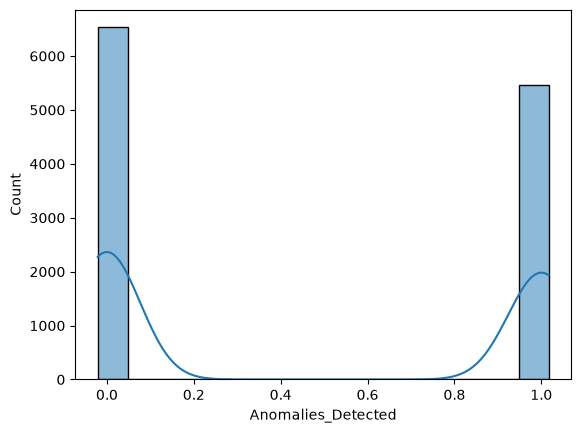

In [33]:
sns.histplot(x_train['Anomalies_Detected'], kde=True)
plt.show()

In [34]:
x_train['Anomalies_Detected'] = (x_train['Anomalies_Detected'] >= 0.5).astype(int)
x_test['Anomalies_Detected'] = (x_test['Anomalies_Detected'] >= 0.5).astype(int)

### 6.6 Predictive Score

The distribution of `Predictive_Score` is examined before transformation.

The feature is constrained to the valid range of 0 to 1 and transformed to reduce the effect of its distribution on the machine learning models.


In [35]:
print(x_train['Predictive_Score'].describe())

count    12000.000000
mean         0.167624
std          0.103591
min         -0.002080
25%          0.087749
50%          0.149081
75%          0.228883
max          0.746689
Name: Predictive_Score, dtype: float64


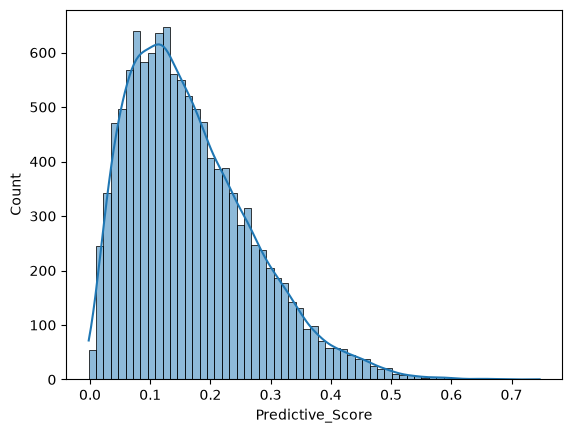

In [36]:
sns.histplot(x_train['Predictive_Score'], kde=True)
plt.show()

In [37]:
x_train['Predictive_Score'] = x_train['Predictive_Score'].clip(lower=0.0, upper=1.0)
x_test['Predictive_Score'] = x_test['Predictive_Score'].clip(lower=0.0, upper=1.0)

In [38]:
x_train['Predictive_Score'] = np.log1p(x_train['Predictive_Score'])
x_test['Predictive_Score'] = np.log1p(x_test['Predictive_Score'])

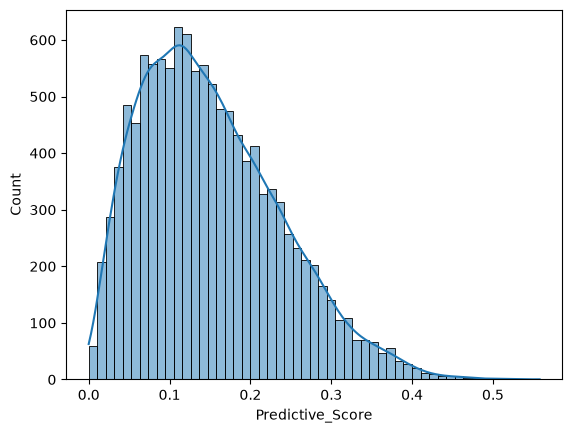

In [39]:
sns.histplot(x_train['Predictive_Score'], kde=True)
plt.show()

### 6.7 Weather Conditions

`Weather_Conditions` is a categorical feature representing the environmental conditions under which the vehicle operates.

The categories are encoded numerically to make them compatible with the machine learning algorithms.


In [40]:
print(df['Weather_Conditions'].unique())

<StringArray>
['Clear', 'Snowy', 'Rainy', 'Windy']
Length: 4, dtype: str


In [41]:
Weather_Conditions = {
    'Clear': 0,
    'Rainy': 1,
    'Snowy': 2,
    'Windy': 3
}
x_train['Weather_Conditions'] = x_train['Weather_Conditions'].map(Weather_Conditions)
x_test['Weather_Conditions'] = x_test['Weather_Conditions'].map(Weather_Conditions)

### 6.8 Road Conditions

`Road_Conditions` represents the type of road environment:

* Urban
* Rural
* Highway

The categorical values are converted into numerical representations for model training.


In [42]:
Road_Conditions = {'Urban': 0, 'Rural': 1, 'Highway': 2}
x_train['Road_Conditions'] = x_train['Road_Conditions'].map(Road_Conditions)
x_test['Road_Conditions'] = x_test['Road_Conditions'].map(Road_Conditions)

### 6.9 Delivery Times

The distribution of `Delivery_Times` is examined for skewness.

A logarithmic transformation is applied to reduce the effect of extreme values and produce a more suitable distribution for algorithms that are sensitive to feature scales and distributions.


In [43]:
print(x_train['Delivery_Times'].describe())

count    12000.000000
mean       100.260887
std         80.156006
min         27.348881
25%         31.081959
50%         71.345805
75%        140.106062
max        302.694460
Name: Delivery_Times, dtype: float64


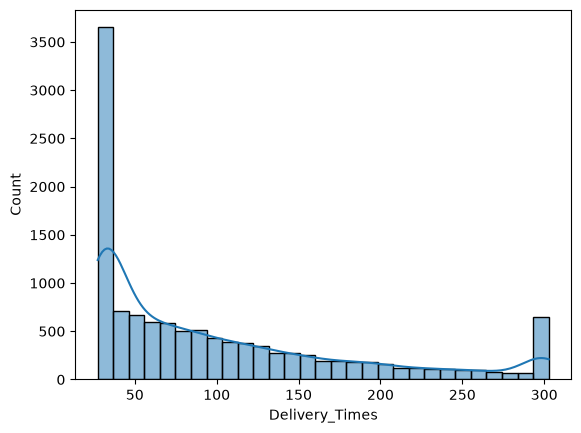

In [44]:
sns.histplot(x_train['Delivery_Times'], kde=True)
plt.show()

In [45]:
x_train['Delivery_Times'] = np.log1p(x_train['Delivery_Times'])
x_test['Delivery_Times'] = np.log1p(x_test['Delivery_Times'])

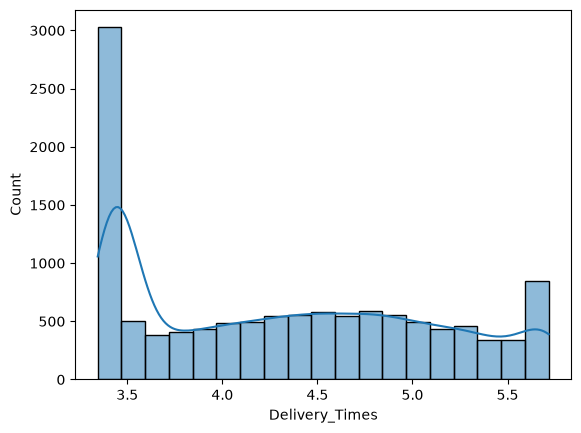

In [46]:
sns.histplot(x_train['Delivery_Times'], kde=True)
plt.show()

### 6.10 Downtime Maintenance


In [47]:
print(x_train['Downtime_Maintenance'].describe())

count    12000.000000
mean         3.250832
std          6.472722
min         -0.213499
25%          0.000000
50%          0.038541
75%          3.884144
max         88.130783
Name: Downtime_Maintenance, dtype: float64


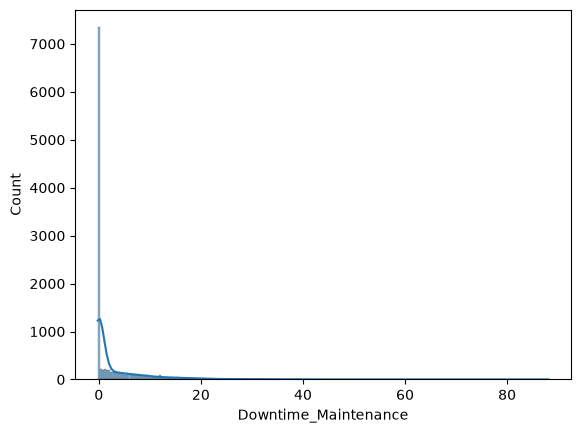

In [48]:
sns.histplot(x_train['Downtime_Maintenance'], kde=True)
plt.show()

In [49]:
x_train['Downtime_Maintenance'] = x_train['Downtime_Maintenance'].clip(lower=0.0)
x_test['Downtime_Maintenance'] = x_test['Downtime_Maintenance'].clip(lower=0.0)

In [50]:
x_train['Downtime_Maintenance'] = np.log1p(x_train['Downtime_Maintenance'])
x_test['Downtime_Maintenance'] = np.log1p(x_test['Downtime_Maintenance'])

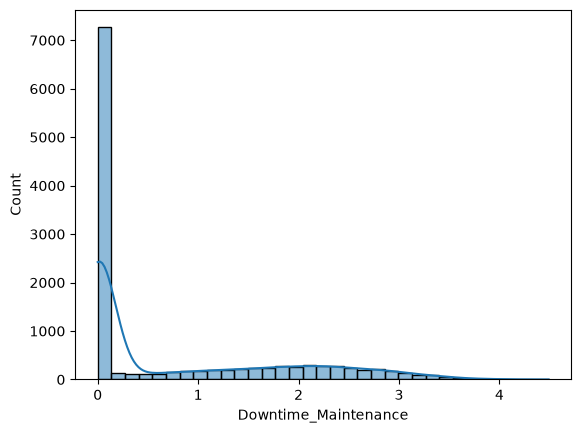

In [51]:
sns.histplot(x_train['Downtime_Maintenance'], kde=True)
plt.show()

### 6.11 Impact on efficiency


In [52]:
print(x_train['Impact_on_Efficiency'].describe())

count    12000.000000
mean         0.208524
std          0.112182
min          0.096586
25%          0.106518
50%          0.179121
75%          0.270306
max          0.822859
Name: Impact_on_Efficiency, dtype: float64


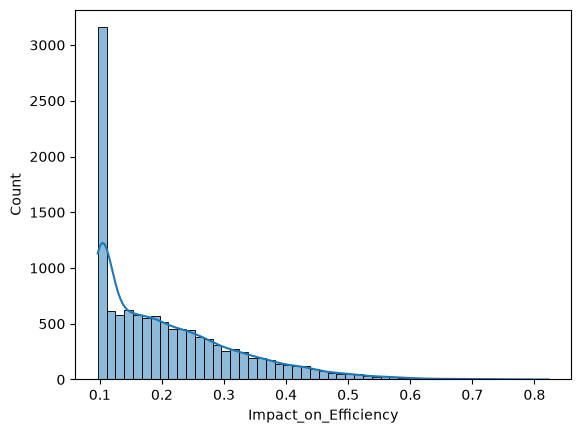

In [53]:
sns.histplot(x_train['Impact_on_Efficiency'], kde=True)
plt.show()

In [54]:
x_train['Impact_on_Efficiency'] = np.log1p(x_train['Impact_on_Efficiency'])
x_test['Impact_on_Efficiency'] = np.log1p(x_test['Impact_on_Efficiency'])

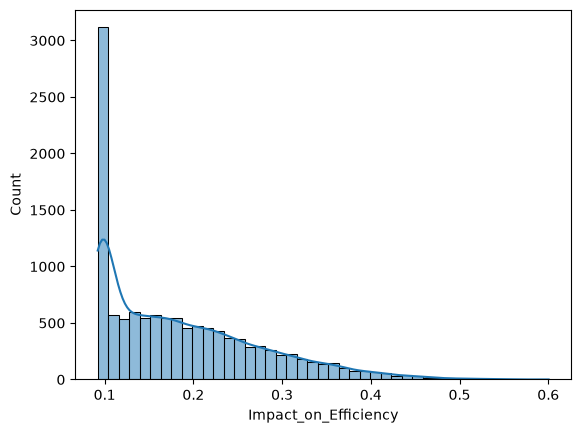

In [55]:
sns.histplot(x_train['Impact_on_Efficiency'], kde=True)
plt.show()

### 6.12 Severity Score


In [56]:
print(x_train['Severity_Score'].describe())

count    12000.000000
mean         0.190024
std          0.099817
min          0.006999
25%          0.118621
50%          0.169855
75%          0.238168
max          0.610795
Name: Severity_Score, dtype: float64


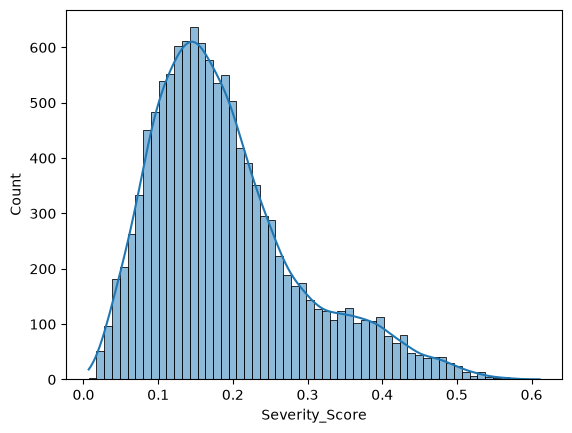

In [57]:
sns.histplot(x_train['Severity_Score'], kde=True)
plt.show()

In [58]:
print(x_test['Severity_Score'].describe())

count    3001.000000
mean        0.187607
std         0.098856
min         0.013200
25%         0.116770
50%         0.169791
75%         0.235311
max         0.557834
Name: Severity_Score, dtype: float64


In [59]:
x_train['Severity_Score'] = np.log1p(x_train['Severity_Score'])
x_test['Severity_Score'] = np.log1p(x_test['Severity_Score'])

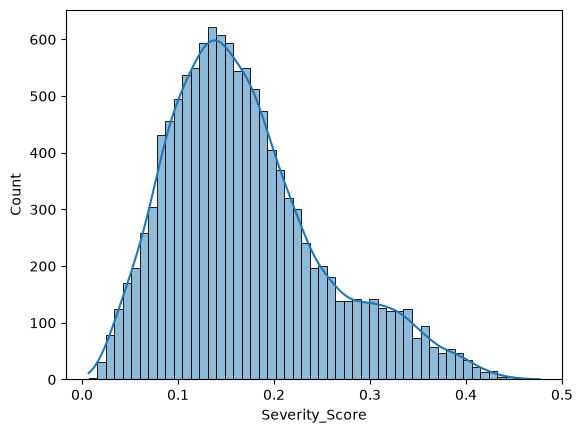

In [60]:
sns.histplot(x_train['Severity_Score'], kde=True)
plt.show()

### 6.13 Vehicle Information

Features that uniquely identify individual vehicles are not useful for generalizing maintenance patterns.

Therefore, `Vehicle_ID` is removed from the feature set.

The vehicle's manufacturing year is instead transformed into a more meaningful feature representing **Vehicle Age**.


In [61]:
x_train = x_train.drop(columns=['Vehicle_ID'])
x_test = x_test.drop(columns=['Vehicle_ID'])

### 6.14 Encoding Make and Model

`Make_and_Model` is a categorical feature containing different vehicle models.

Target encoding is used to convert the categorical values into numerical representations. The encoder is fitted using the training data and the corresponding target values, then applied to the test data.

This approach avoids fitting the encoder using information from the test set.


In [62]:
target_encoder = TargetEncoder(
    cols=['Make_and_Model'],
    handle_missing='value',
    handle_unknown='value'
)
x_train = target_encoder.fit_transform(
    x_train,
    y_train
)
x_test = target_encoder.transform(
    x_test
)

In [63]:
x_train.head()

,Make_and_Model,Year_of_Manufacture,Vehicle_Type,Usage_Hours,Route_Info,Load_Capacity,Actual_Load,Last_Maintenance_Date,Maintenance_Type,Maintenance_Cost,...,Brake_Condition,Failure_History,Anomalies_Detected,Predictive_Score,Weather_Conditions,Road_Conditions,Delivery_Times,Downtime_Maintenance,Impact_on_Efficiency,Severity_Score
6025,1.169223,2022.078878,Truck,1571.804512,Highway,3.392350,3.675942,2023-03-31,Oil Change,268.390488,...,0,1,1,0.178374,0,1,5.716022,1.974527,0.093271,0.236303
12725,1.147107,2015.895021,Truck,651.600711,Highway,4.346232,4.215813,2023-02-21,Tire Rotation,116.146531,...,2,0,1,0.105459,0,0,3.412087,0.075421,0.095570,0.128525
10224,1.179380,2013.969761,Van,4066.225082,Rural,7.306369,4.884554,2023-10-12,Oil Change,402.819922,...,0,1,0,0.078093,0,2,4.306952,2.564755,0.441475,0.094895
1949,1.169223,2008.045912,Van,84.462622,Rural,10.104629,7.728222,2024-03-29,Oil Change,229.717442,...,2,0,0,0.141083,0,2,4.334407,0.001035,0.094589,0.069738
11656,1.147107,2016.973882,Truck,425.067516,Urban,8.494497,8.016137,2023-10-09,Tire Rotation,499.076518,...,2,1,0,0.021977,0,2,5.306249,1.670897,0.213214,0.193000


In [64]:
x_train = x_train.rename(columns={'Make_and_Model': 'Make_and_Model_Encoded'})
x_test = x_test.rename(columns={'Make_and_Model': 'Make_and_Model_Encoded'})

### 6.15 Vehicle Age

The manufacturing year is transformed into `Vehicle_Age` by calculating the number of years between the manufacturing year and the reference year.

The original `Year_of_Manufacture` feature is then removed because the derived age provides a more directly interpretable representation.


years of manfucature


In [65]:
current_year = 2026

x_train['Vehicle_Age'] = (
    current_year - x_train['Year_of_Manufacture']
)

x_train = x_train.drop(columns=['Year_of_Manufacture'])

x_test['Vehicle_Age'] = (
    current_year - x_test['Year_of_Manufacture']
)

x_test = x_test.drop(columns=['Year_of_Manufacture'])

### 6.16 Vehicle Type


In [66]:
vehicle_type = {'Van': 0, 'Truck': 1}
x_train['Vehicle_Type'] = x_train['Vehicle_Type'].map(vehicle_type)
x_test['Vehicle_Type'] = x_test['Vehicle_Type'].map(vehicle_type)

Usage Hours


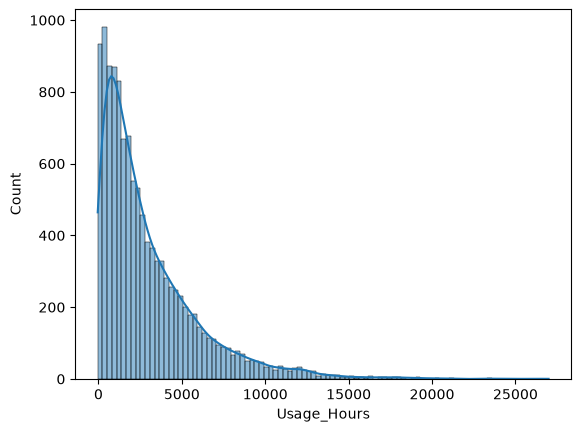

In [67]:
sns.histplot(x_train['Usage_Hours'], kde=True)
plt.show()

In [68]:
print(df['Usage_Hours'].describe())

count    15001.000000
mean      2991.824039
std       3012.435954
min        -47.414131
25%        874.000000
50%       2043.361636
75%       4141.935728
max      26988.000000
Name: Usage_Hours, dtype: float64


In [69]:
x_train['Usage_Hours'] = x_train['Usage_Hours'].clip(lower=0)
x_test['Usage_Hours'] = x_test['Usage_Hours'].clip(lower=0)

In [70]:
x_train['Usage_Hours'] = np.log1p(x_train['Usage_Hours'])
x_test['Usage_Hours'] = np.log1p(x_test['Usage_Hours'])

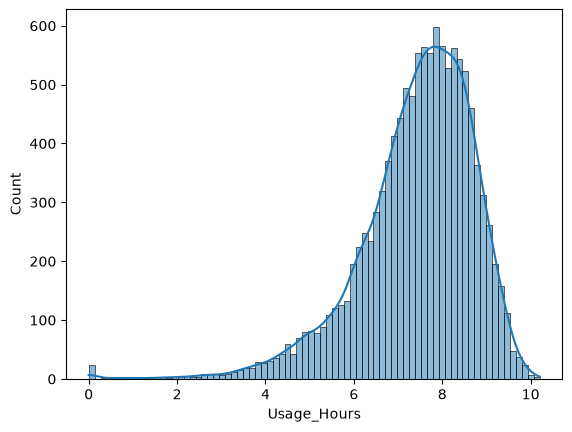

In [71]:
sns.histplot(x_train['Usage_Hours'], kde=True)
plt.show()

route info


In [72]:
x_train=x_train.drop(columns=['Route_Info'])
x_test=x_test.drop(columns=['Route_Info'])

Load Capacity and acutal Load


In [73]:
x_train['capacity_ratio']=x_train['Actual_Load']/x_train['Load_Capacity']
x_test['capacity_ratio']=x_test['Actual_Load']/x_test['Load_Capacity']
x_train=x_train.drop(columns=['Load_Capacity','Actual_Load'])
x_test=x_test.drop(columns=['Load_Capacity','Actual_Load'])

### 6.17 Last Maintenance Date

The `Last_Maintenance_Date` feature is converted from a date representation into a numerical feature.

`Days_Since_Maintenance` is calculated to represent how many days have passed since the last maintenance.

The original date column is then removed because machine learning models require numerical representations of this information.


In [74]:
x_train['Last_Maintenance_Date'] = pd.to_datetime(x_train['Last_Maintenance_Date'])
x_test['Last_Maintenance_Date'] = pd.to_datetime(x_test['Last_Maintenance_Date'])

In [75]:
reference_date = pd.Timestamp('2026-01-01')
x_train['Days_Since_Maintenance'] = (reference_date - x_train['Last_Maintenance_Date']).dt.days
x_test['Days_Since_Maintenance'] = (reference_date - x_test['Last_Maintenance_Date']).dt.days

In [76]:
x_train = x_train.drop(columns=['Last_Maintenance_Date'])
x_test = x_test.drop(
    columns=['Last_Maintenance_Date']
)

### 6.18 Encoding Maintenance Type

`Maintenance_Type` is a categorical feature.

One-hot encoding is applied to convert each category into a separate binary feature. The encoder uses `handle_unknown='ignore'` so that unseen categories in the test set do not cause errors.


In [77]:
one_hot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

maintenance_train = one_hot_encoder.fit_transform(
    x_train[['Maintenance_Type']]
)

maintenance_test = one_hot_encoder.transform(
    x_test[['Maintenance_Type']]
)

In [78]:
encoded_cols = one_hot_encoder.get_feature_names_out(
    ['Maintenance_Type']
)

print(encoded_cols)

['Maintenance_Type_Engine Overhaul' 'Maintenance_Type_Oil Change'
 'Maintenance_Type_Tire Rotation']


In [79]:
maintenance_train_df = pd.DataFrame(
    maintenance_train,
    columns=encoded_cols,
    index=x_train.index
)

maintenance_test_df = pd.DataFrame(
    maintenance_test,
    columns=encoded_cols,
    index=x_test.index
)

In [80]:
x_train = pd.concat(
    [
        x_train.drop(columns=['Maintenance_Type']),
        maintenance_train_df
    ],
    axis=1
)

x_test = pd.concat(
    [
        x_test.drop(columns=['Maintenance_Type']),
        maintenance_test_df
    ],
    axis=1
)

In [81]:
print(x_train.head())
print(x_train.columns)

       Make_and_Model_Encoded  Vehicle_Type  Usage_Hours  Maintenance_Cost  \
6025                 1.169223             1     7.360616        268.390488   
12725                1.147107             1     6.480965        116.146531   
10224                1.179380             0     8.310716        402.819922   
1949                 1.169223             0     4.448079        229.717442   
11656                1.147107             1     6.054598        499.076518   

       Engine_Temperature  Tire_Pressure  Fuel_Consumption  Battery_Status  \
6025                120.0      55.088331         20.153904       49.983539   
12725               120.0      19.798358         12.063401       45.014148   
10224               120.0      55.083560          5.067202       45.016929   
1949                120.0      19.834610          6.420908       45.021867   
11656               120.0      38.659283         20.018609       44.990992   

       Vibration_Levels  Oil_Quality  ...  Delivery_Times  \
6

In [82]:
display(x_train.head())

,Make_and_Model_Encoded,Vehicle_Type,Usage_Hours,Maintenance_Cost,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,...,Delivery_Times,Downtime_Maintenance,Impact_on_Efficiency,Severity_Score,Vehicle_Age,capacity_ratio,Days_Since_Maintenance,Maintenance_Type_Engine Overhaul,Maintenance_Type_Oil Change,Maintenance_Type_Tire Rotation
6025,1.169223,1,7.360616,268.390488,120.0,55.088331,20.153904,49.983539,0.605401,82.758444,...,5.716022,1.974527,0.093271,0.236303,3.921122,1.083597,1007,0.0,1.0,0.0
12725,1.147107,1,6.480965,116.146531,120.0,19.798358,12.063401,45.014148,1.066044,72.905250,...,3.412087,0.075421,0.095570,0.128525,10.104979,0.969993,1045,0.0,0.0,1.0
10224,1.179380,0,8.310716,402.819922,120.0,55.083560,5.067202,45.016929,1.169719,77.068872,...,4.306952,2.564755,0.441475,0.094895,12.030239,0.668534,812,0.0,1.0,0.0
1949,1.169223,0,4.448079,229.717442,120.0,19.834610,6.420908,45.021867,1.511354,81.071202,...,4.334407,0.001035,0.094589,0.069738,17.954088,0.764820,643,0.0,1.0,0.0
11656,1.147107,1,6.054598,499.076518,120.0,38.659283,20.018609,44.990992,2.444561,74.322137,...,5.306249,1.670897,0.213214,0.193000,9.026118,0.943686,815,0.0,0.0,1.0


Maintenance_Cost


In [83]:
print(x_train['Maintenance_Cost'].describe())

count    12000.000000
mean      1056.847814
std       1587.083676
min         56.898490
25%        229.564314
50%        351.654552
75%        478.530126
max       6015.568501
Name: Maintenance_Cost, dtype: float64


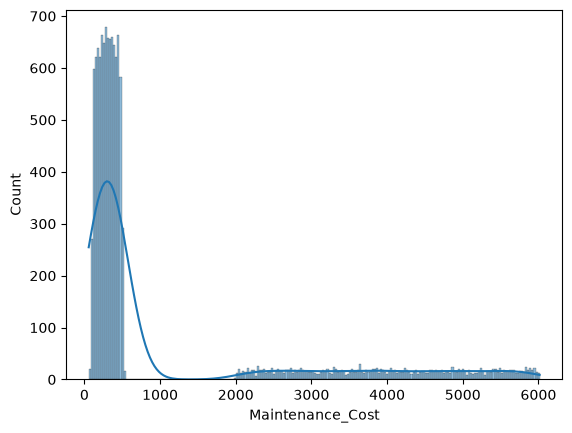

In [84]:
sns.histplot(x_train['Maintenance_Cost'], kde=True)
plt.show()

In [85]:
x_train['Maintenance_Cost'] = np.log1p(
    x_train['Maintenance_Cost']
)
x_test['Maintenance_Cost'] = np.log1p(
    x_test['Maintenance_Cost']
)

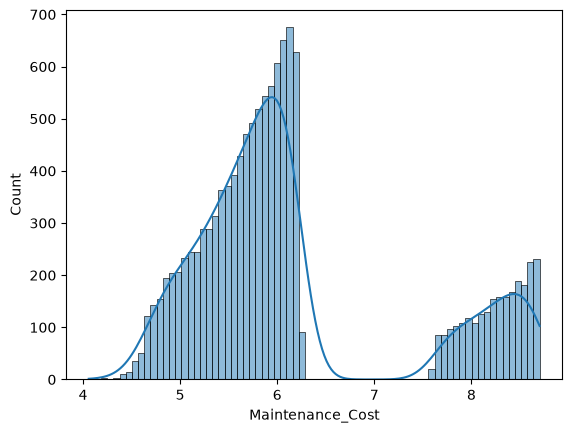

In [86]:
sns.histplot(x_train['Maintenance_Cost'], kde=True)
plt.show()

Engine Temp


In [87]:
x_train=x_train.drop(columns=['Engine_Temperature'])
x_test=x_test.drop(columns=['Engine_Temperature'])

tire pressure


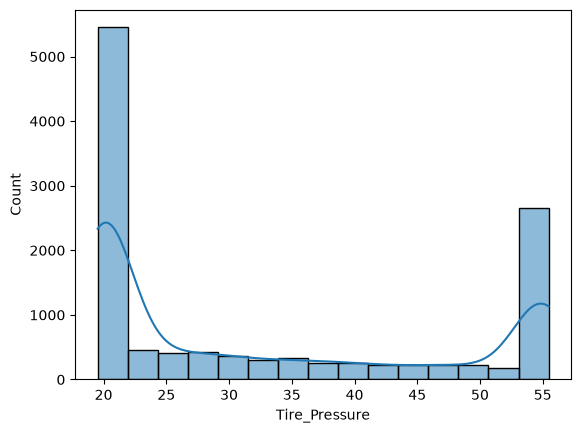

In [88]:
sns.histplot(x_train[ 'Tire_Pressure'], kde=True)
plt.show()

In [89]:
print(x_train['Tire_Pressure'].describe())

count    12000.000000
mean        32.633711
std         14.468580
min         19.531922
25%         20.000000
50%         24.892285
75%         48.922440
max         55.471451
Name: Tire_Pressure, dtype: float64


In [90]:
x_train['Tire_Pressure'] = np.log1p(
    x_train['Tire_Pressure']
)
x_test['Tire_Pressure'] = np.log1p(
    x_test['Tire_Pressure']
)

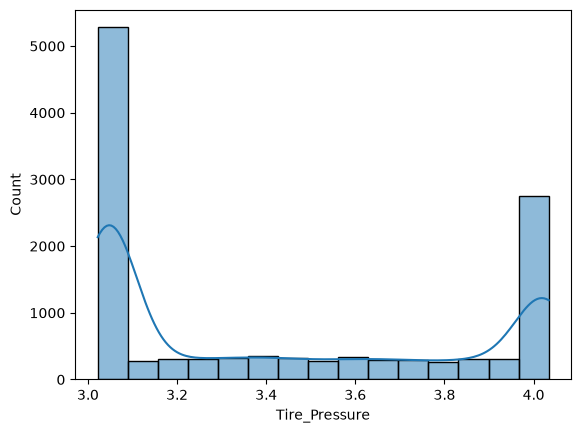

In [91]:
sns.histplot(x_train['Tire_Pressure'], kde=True)
plt.show()

fuel consumption


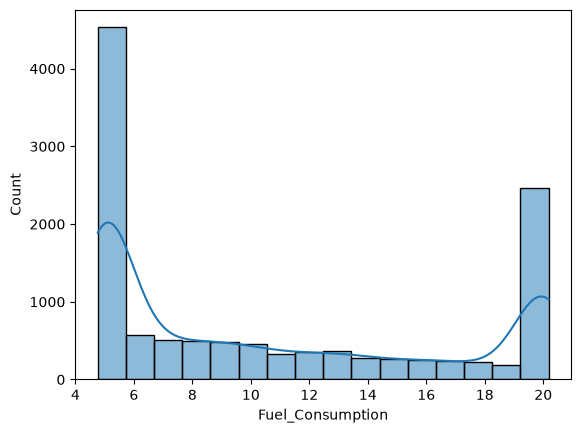

In [92]:
sns.histplot(x_train['Fuel_Consumption'], kde=True)
plt.show()

In [93]:
print(x_train['Fuel_Consumption'].describe())

count    12000.000000
mean        10.672193
std          5.980073
min          4.762652
25%          5.011649
50%          8.416620
75%         16.729224
max         20.183594
Name: Fuel_Consumption, dtype: float64


In [94]:
x_train['Fuel_Consumption'] = np.log1p(x_train['Fuel_Consumption'])
x_test['Fuel_Consumption'] = np.log1p(x_test['Fuel_Consumption'])

### 6.19 Battery Status

The battery status is converted into a binary indicator called `Is_Battery_Elevated`.

This feature identifies whether the battery status exceeds the selected threshold, after which the original continuous feature is removed.


In [95]:
print(x_train['Battery_Status'].describe())

count    12000.000000
mean        45.675771
std          1.640963
min         44.939186
25%         44.998889
50%         45.000000
75%         45.015791
max         50.048393
Name: Battery_Status, dtype: float64


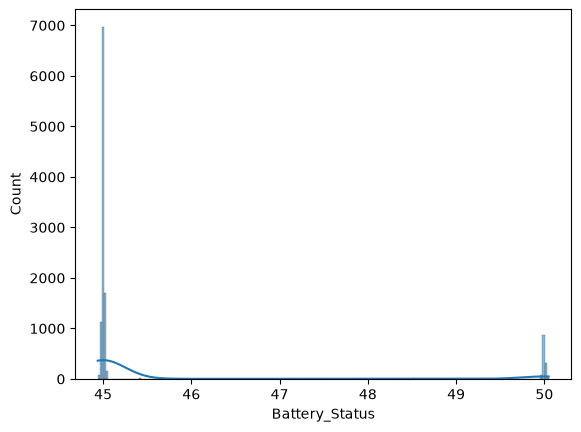

In [96]:
sns.histplot(x_train['Battery_Status'], kde=True)
plt.show()

In [97]:
x_train['Is_Battery_Elevated'] = (x_train['Battery_Status'] > 47.5).astype(int)
x_test['Is_Battery_Elevated'] = (x_test['Battery_Status'] > 47.5).astype(int)
x_train = x_train.drop(columns=['Battery_Status'])
x_test = x_test.drop(columns=['Battery_Status'])

In [98]:
display(x_train.head())

,Make_and_Model_Encoded,Vehicle_Type,Usage_Hours,Maintenance_Cost,Tire_Pressure,Fuel_Consumption,Vibration_Levels,Oil_Quality,Brake_Condition,Failure_History,...,Downtime_Maintenance,Impact_on_Efficiency,Severity_Score,Vehicle_Age,capacity_ratio,Days_Since_Maintenance,Maintenance_Type_Engine Overhaul,Maintenance_Type_Oil Change,Maintenance_Type_Tire Rotation,Is_Battery_Elevated
6025,1.169223,1,7.360616,5.596162,4.026928,3.051824,0.605401,82.758444,0,1,...,1.974527,0.093271,0.236303,3.921122,1.083597,1007,0.0,1.0,0.0,1
12725,1.147107,1,6.480965,4.763426,3.034874,2.569815,1.066044,72.905250,2,0,...,0.075421,0.095570,0.128525,10.104979,0.969993,1045,0.0,0.0,1.0,0
10224,1.179380,0,8.310716,6.000969,4.026843,1.802898,1.169719,77.068872,0,1,...,2.564755,0.441475,0.094895,12.030239,0.668534,812,0.0,1.0,0.0,0
1949,1.169223,0,4.448079,5.441194,3.036616,2.004301,1.511354,81.071202,2,0,...,0.001035,0.094589,0.069738,17.954088,0.764820,643,0.0,1.0,0.0,0
11656,1.147107,1,6.054598,6.214761,3.680325,3.045408,2.444561,74.322137,2,1,...,1.670897,0.213214,0.193000,9.026118,0.943686,815,0.0,0.0,1.0,0


In [99]:
x_train['Is_Overloaded'] = (x_train['capacity_ratio'] > 1.0).astype(int)
x_test['Is_Overloaded'] = (x_test['capacity_ratio'] > 1.0).astype(int)


 6.20
 Removing Leaky Features

In [110]:
x_train = x_train.drop(columns=[ 'Predictive_Score',
    'Severity_Score',])
x_test = x_test.drop(columns=[ 'Predictive_Score',
    'Severity_Score',])

## 7. Preprocessing Summary

At this stage, the dataset has been prepared for machine learning.

The preprocessing steps included:

* Cleaning invalid numerical values
* Handling outliers
* Applying transformations to selected numerical features
* Encoding categorical variables
* Creating new meaningful features
* Converting date information into numerical features
* Removing irrelevant features
* Creating binary indicators
* Standardizing the features for algorithms that are sensitive to feature scale

The resulting training and testing datasets are now ready for model implementation.


## Feature Scaling for Scale-Sensitive Models

In [111]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 8. Models

## Logistic Regression

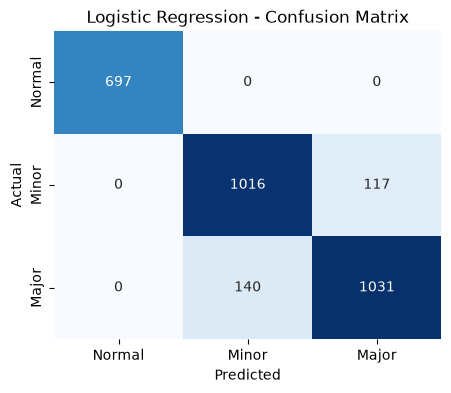

Logistic Regression Results:
Accuracy : 0.9143618793735422
Precision: 0.9145089605041571
Recall   : 0.9143618793735422


In [119]:
logistic = LogisticRegression(class_weight='balanced', random_state=42)
logistic.fit(x_train_scaled, y_train)
y_pred_logistic = logistic.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_logistic, average='weighted'))


## SVM

c:\Users\CM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


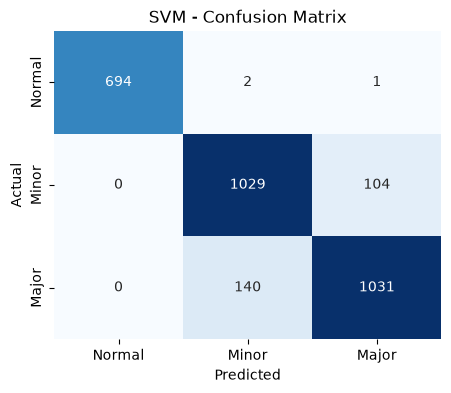

SVM Results:
Accuracy : 0.9176941019660113
Precision: 0.9181516135007675
Recall   : 0.9176941019660113


In [113]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, probability=True, random_state=42))
])
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM - Confusion Matrix')
plt.show()

print("SVM Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))

## KNN

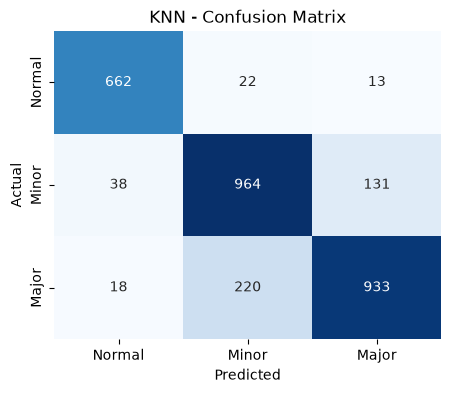

KNN Results:
Accuracy : 0.8527157614128624
Precision: 0.8539547025747936
Recall   : 0.8527157614128624


In [120]:
knn = KNeighborsClassifier(n_neighbors=5,weights='distance', metric='minkowski', p=2)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.show()

print("KNN Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_knn, average='weighted'))

## Decision Tree

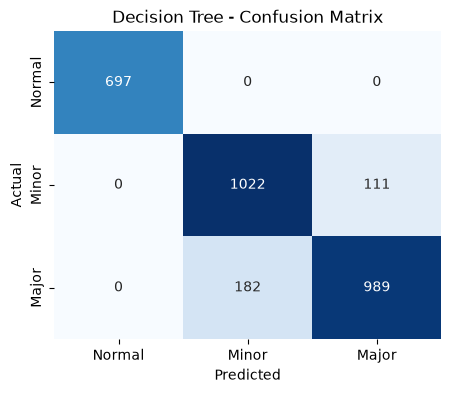

Decision Tree Results:
Accuracy : 0.9023658780406532
Precision: 0.903554819288567
Recall   : 0.9023658780406532


In [123]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

print("Decision Tree Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))

## Extra Trees

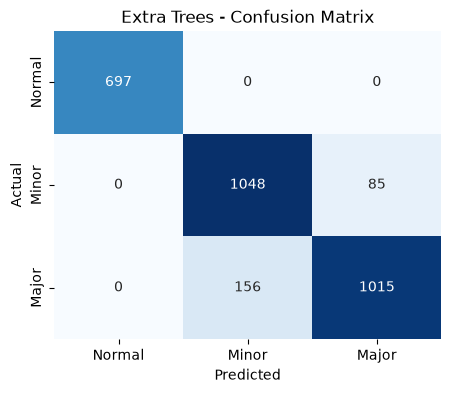

Extra Trees Results:
Accuracy : 0.9196934355214929
Precision: 0.9209306804104663
Recall   : 0.9196934355214929


In [124]:
et = ExtraTreesClassifier(n_estimators=200, random_state=42,max_depth=15,
    min_samples_split=5,)
et.fit(x_train, y_train)
y_pred_et = et.predict(x_test)

cm = confusion_matrix(y_test, y_pred_et)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Extra Trees - Confusion Matrix')
plt.show()

print("Extra Trees Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_et))
print("Precision:", precision_score(y_test, y_pred_et, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_et, average='weighted'))

## Random Forest

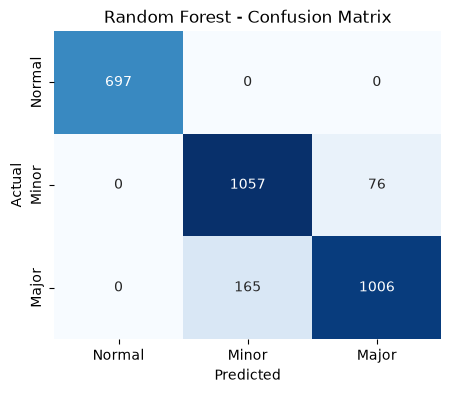

Random Forest Results:
Accuracy : 0.9196934355214929
Precision: 0.9216147279643754
Recall   : 0.9196934355214929


In [125]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=15,        # يحدد الـ overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

print("Random Forest Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))

## Ensemble Model: Voting Classifier

A soft Voting Classifier is used to combine the predictions of multiple classification models.

c:\Users\CM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


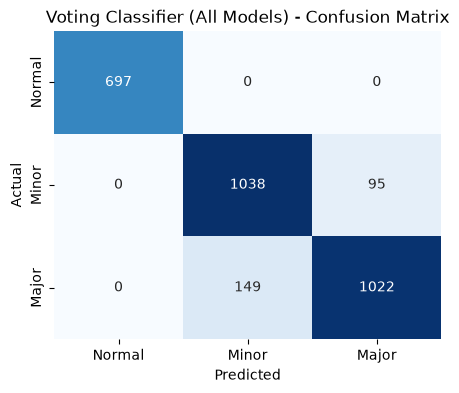

Voting Classifier (All 6 Models) Results:
Accuracy : 0.9186937687437521
Precision: 0.9194221173331031
Recall   : 0.9186937687437521


In [126]:
logistic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

voting = VotingClassifier(
    estimators=[
        ('logistic', logistic_pipe),
        ('svm', svm),
        ('knn', knn_pipe),
        ('dt', dt),
        ('et', et),
        ('rf', rf)
    ],
    voting='soft'
)

voting.fit(x_train, y_train)
y_pred_voting = voting.predict(x_test)

cm = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Minor', 'Major'],
            yticklabels=['Normal', 'Minor', 'Major'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Voting Classifier (All Models) - Confusion Matrix')
plt.show()

print("Voting Classifier (All 6 Models) Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_voting))
print("Precision:", precision_score(y_test, y_pred_voting, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_voting, average='weighted'))

## 9. Best Model
The models are compared based on their accuracy, precision, and recall.

The model with the highest accuracy is selected as the best-performing model.

In [127]:
models = {
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'Extra Trees': y_pred_et,
    'Voting Classifier': y_pred_voting,
    'KNN': y_pred_knn,
    'Logistic Regression': y_pred_logistic
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

results_df

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("Model Comparison:")
display(results_df)

best_model = results_df.iloc[0]

print("\nBest Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall:", round(best_model['Recall'], 4))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.919693,0.921615,0.919693,0.919625
2,Extra Trees,0.919693,0.920931,0.919693,0.919658
3,Voting Classifier,0.918694,0.919422,0.918694,0.918681
0,SVM,0.917694,0.918152,0.917694,0.917750
5,Logistic Regression,0.914362,0.914509,0.914362,0.914367
4,KNN,0.852716,0.853955,0.852716,0.852417



Best Model: Random Forest
Accuracy: 0.9197
Precision: 0.9216
Recall: 0.9197


In [128]:
best_model_name = best_model['Model']
best_predictions = models[best_model_name]

print(f"Classification Report for Best Model: {best_model_name}\n")
print(classification_report(y_test, best_predictions))

Classification Report for Best Model: Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       697
           1       0.86      0.93      0.90      1133
           2       0.93      0.86      0.89      1171

    accuracy                           0.92      3001
   macro avg       0.93      0.93      0.93      3001
weighted avg       0.92      0.92      0.92      3001

